In [41]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import torch

from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from src.models.vae import ConvVAE, VAEConfig
from src.data.dsprites import get_dataloaders

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

# 1. Loading and Embedding

In [42]:
CHECKPOINT = ROOT / "results/dsprites/dsprites_vae_baseline/epoch_0150.pt"
NPZ_PATH   = ROOT / "data/dsprites/dsprites.npz"
SEED       = 48025845
BATCH_SIZE = 512

FACTORS = [
    ("shape",       1, "categorical", {1: "square", 2: "ellipse", 3: "heart"}),
    ("scale",       2, "continuous",  None),
    ("orientation", 3, "continuous",  None),
    ("x_position",  4, "continuous",  None),
    ("y_position",  5, "continuous",  None),
]

In [43]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.serialization.add_safe_globals([VAEConfig])

ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
vae_cfg = ckpt["model_config"]

model = ConvVAE(vae_cfg).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print(f"Loaded epoch {ckpt['epoch']} | val loss {ckpt['metrics']['loss']:.4f}")
print(f"Latent dim: {vae_cfg.latent_dim}")

Loaded epoch 150 | val loss 36.8996
Latent dim: 8


In [45]:
_, _, test_loader = get_dataloaders(
    npz_path=str(NPZ_PATH),
    batch_size=BATCH_SIZE,
    val_fraction=0.1,
    test_fraction=0.1,
    num_workers=0,
    seed=SEED,
    include_labels=True,
)

all_mu, all_labels = [], []

with torch.no_grad():
    for imgs, labels, _ in test_loader:
        mu, _ = model.encode(imgs.to(DEVICE))
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

mu     = np.concatenate(all_mu,     axis=0)
labels = np.concatenate(all_labels, axis=0)

print(f"Encoded {len(mu):,} images | mu shape: {mu.shape}")

Encoded 73,728 images | mu shape: (73728, 8)


In [46]:
def make_3d_plotly_grid(emb3d, labels, factors, title, axis_labels=("Dim 1", "Dim 2", "Dim 3")):
    rows, cols = 2, 3
    cb_x = [0.30, 0.65, 1.00]
    cb_y = [0.78, 0.22]

    fig = make_subplots(
        rows=rows, cols=cols,
        specs=[[{"type": "scene"}] * cols] * rows,
        subplot_titles=[name for name, *_ in factors],
    )

    for i, (name, col, kind, label_map) in enumerate(factors):
        r, c = i // cols + 1, i % cols + 1
        color_vals = labels[:, col].reshape(-1)

        if kind == "categorical":
            colorscale = [[0.0, "#4C72B0"], [0.5, "#DD8452"], [1.0, "#55A868"]]
            unique_vals = sorted(np.unique(color_vals))
            cb_extra = dict(
                tickvals=unique_vals,
                ticktext=[label_map.get(int(v), str(int(v))) for v in unique_vals],
            ) if label_map else {}
        else:
            colorscale = "Viridis"
            cb_extra = {}

        fig.add_trace(go.Scatter3d(
            x=emb3d[:, 0], y=emb3d[:, 1], z=emb3d[:, 2],
            mode="markers", name=name,
            marker=dict(
                size=1.5, color=color_vals,
                colorscale=colorscale, opacity=0.6, showscale=True,
                colorbar=dict(thickness=10, len=0.35, x=cb_x[c-1], y=cb_y[r-1],
                              title=dict(text=name, font=dict(size=9)),
                              tickfont=dict(size=8), **cb_extra),
            ),
        ), row=r, col=c)
        fig.update_scenes(xaxis_title=axis_labels[0], yaxis_title=axis_labels[1],
                          zaxis_title=axis_labels[2], row=r, col=c)

    fig.update_layout(height=900, width=1300, title=title, showlegend=False)
    return fig


def plot_factor_scatter(ax, emb, vals, name, kind, label_map=None):
    if kind == "categorical":
        for v in np.unique(vals):
            lbl = label_map.get(int(v), str(int(v))) if label_map else str(int(v))
            ax.scatter(emb[vals == v, 0], emb[vals == v, 1], s=1, label=lbl)
        ax.legend(title=name, fontsize=6, markerscale=4)
    else:
        plt.colorbar(ax.scatter(emb[:, 0], emb[:, 1], c=vals, s=1, cmap="viridis"),
                     ax=ax, pad=0.01, fraction=0.03)


def plot_embedding_grid_2d(emb, labels, factors, title, xlabel, ylabel, out_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(12, 9))
    fig.suptitle(title, fontsize=11)
    for ax, (name, col, kind, label_map) in zip(axes.flat, factors):
        plot_factor_scatter(ax, emb, labels[:, col], name, kind, label_map)
        ax.set_title(name, fontsize=8); ax.set_xlabel(xlabel, fontsize=7); ax.set_ylabel(ylabel, fontsize=7)
    for ax in axes.flat[len(factors):]: ax.set_visible(False)
    plt.tight_layout()
    if out_path: plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
dim_var = mu.var(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
x    = np.arange(mu.shape[1])
bars = ax.bar(x, dim_var, color="steelblue", label="mu variance")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="prior variance = 1")
ax.set_xlabel("Latent dimension"); ax.set_ylabel("Variance of mu across dataset")
ax.set_title("Active latent dimensions"); ax.set_xticks(x); ax.legend()

for bar, v in zip(bars, dim_var):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05, f"{v:.4f}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "results/figures/latent_dim_variance.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. PCA

In [ ]:
pca   = PCA(n_components=3)
mu_pc = pca.fit_transform(mu)

print(f"mu_pc shape : {mu_pc.shape}")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})")

make_3d_plotly_grid(mu_pc, labels, FACTORS,
    title="PCA of latent space — coloured by generative factors",
    axis_labels=("PC1", "PC2", "PC3")).show()

# 3. UMAP

In [ ]:
print("Fitting UMAP (3-D)...")
mu_umap = UMAP(n_components=3, n_neighbors=7, min_dist=0.1,
               random_state=SEED, n_jobs=1).fit_transform(mu)
print(f"mu_umap shape: {mu_umap.shape}")

make_3d_plotly_grid(mu_umap, labels, FACTORS,
    title="UMAP (3-D) of latent space — coloured by generative factors",
    axis_labels=("UMAP 1", "UMAP 2", "UMAP 3")).show()

In [ ]:
plot_embedding_grid_2d(mu_umap[:, :2], labels, FACTORS,
    title="UMAP (2-D projection) of latent space",
    xlabel="UMAP 1", ylabel="UMAP 2",
    out_path=ROOT / "results/figures/umap_latent.png")

# 4. t-SNE

In [ ]:
# print("Fitting t-SNE (3-D)...")
# mu_tsne = TSNE(n_components=3, perplexity=30, learning_rate="auto",
#                init="pca", random_state=SEED).fit_transform(mu)
# print(f"mu_tsne shape: {mu_tsne.shape}")
#
# make_3d_plotly_grid(mu_tsne, labels, FACTORS,
#     title="t-SNE (3-D) of latent space — coloured by generative factors",
#     axis_labels=("t-SNE 1", "t-SNE 2", "t-SNE 3")).show()

# 5. Latent Traversal

In [ ]:
STEPS = 12
DIM_RANGE = 3.0

fig, axes = plt.subplots(vae_cfg.latent_dim, STEPS,
    figsize=(STEPS * 1.2, vae_cfg.latent_dim * 1.2))
fig.suptitle("Latent Traversal (each row is a dimension)", fontsize=12)

with torch.no_grad():
    for dim in range(vae_cfg.latent_dim):
        for step, val in enumerate(np.linspace(-DIM_RANGE, DIM_RANGE, STEPS)):
            z = torch.zeros(1, vae_cfg.latent_dim, device=DEVICE)
            z[0, dim] = val
            img = torch.sigmoid(model.decode(z)).squeeze().cpu().numpy()
            axes[dim, step].imshow(img, cmap="gray", vmin=0, vmax=1)
            axes[dim, step].axis("off")
        axes[dim, 0].set_ylabel(f"dim {dim}", rotation=0, labelpad=30, va="center", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "results/figures/latent_traversal.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Latent Interpolation

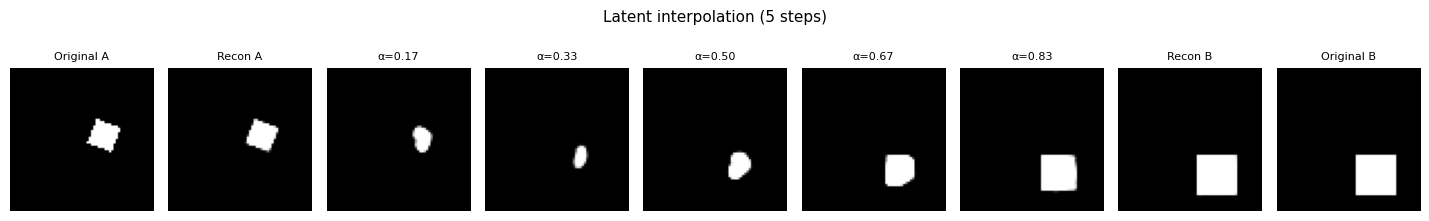

In [50]:
INTERP_STEPS = 5

# Sample 2 random images from the test set
sample_loader = torch.utils.data.DataLoader(
    test_loader.dataset, batch_size=64, shuffle=True, num_workers=0)
imgs_ab = next(iter(sample_loader))[0][:2].to(DEVICE)   # (2, C, H, W)

with torch.no_grad():
    mu_a, _ = model.encode(imgs_ab[[0]])
    mu_b, _ = model.encode(imgs_ab[[1]])
    alphas   = np.linspace(0, 1, INTERP_STEPS + 2)   # includes 0.0 and 1.0
    z_interp = torch.stack([(1 - a) * mu_a + a * mu_b for a in alphas]).squeeze(1)
    decoded  = torch.sigmoid(model.decode(z_interp))  # (steps+2, C, H, W)

def to_np(t):
    t = t.detach().cpu().squeeze()
    return t.numpy() if t.ndim == 2 else t.permute(1, 2, 0).numpy()

n_cols = INTERP_STEPS + 4   # orig_a + recon_a + steps + recon_b + orig_b
fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 1.6, 2.4))
fig.suptitle(f"Latent interpolation ({INTERP_STEPS} steps)", fontsize=11)

def show(ax, img, title):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1); ax.set_title(title, fontsize=8); ax.axis("off")

show(axes[0],  to_np(imgs_ab[0]),  "Original A")
show(axes[1],  to_np(decoded[0]),  "Recon A")
for i in range(INTERP_STEPS):
    show(axes[2 + i], to_np(decoded[1 + i]), f"\u03b1={alphas[1 + i]:.2f}")
show(axes[-2], to_np(decoded[-1]), "Recon B")
show(axes[-1], to_np(imgs_ab[1]),  "Original B")

plt.tight_layout()
plt.savefig(ROOT / "results/figures/latent_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()